# Pipeline Overview Stats

In [51]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pipeline.paths import project_paths

# Load data
PROJECT = "qwen35_27b_full"
paths = project_paths(PROJECT)

dataset = []
with open(paths.dataset) as f:
    for line in f:
        dataset.append(json.loads(line))

runs = {}
with open(paths.runs) as f:
    for line in f:
        r = json.loads(line)
        runs[r["run_id"]] = r

labels = {}
with open(paths.labels) as f:
    for line in f:
        l = json.loads(line)
        labels[l["run_id"]] = l

print(f"Dataset questions: {len(dataset)}")
print(f"Runs: {len(runs)}")
print(f"Labels: {len(labels)}")


Dataset questions: 498
Runs: 1992
Labels: 1992


## Successful Responses by Hint Type
How many questions produced a valid run (i.e. didn't fail before generating an answer) out of the total dataset, broken down by hint type.

In [52]:
HINT_TYPES = ["none", "metadata", "grader_hacking", "unethical"]
HINT_LABELS = ["None (baseline)", "Metadata", "Grader hacking", "Unethical"]

question_ids = [q["question_id"] for q in dataset]
n_questions = len(question_ids)

print(f"Total questions in dataset: {n_questions}\n")
print(f"{'Hint type':<20} {'Runs':>6} {'/ Total':>8} {'Rate':>8}")
print("-" * 44)

runs_by_hint = {}
for ht in HINT_TYPES:
    completed = [qid for qid in question_ids if f"{qid}__{ht}" in runs]
    runs_by_hint[ht] = completed
    rate = len(completed) / n_questions
    label = HINT_LABELS[HINT_TYPES.index(ht)]
    print(f"{label:<20} {len(completed):>6} / {n_questions:<6} {rate:>7.1%}")

Total questions in dataset: 498

Hint type              Runs  / Total     Rate
--------------------------------------------
None (baseline)         498 / 498     100.0%
Metadata                498 / 498     100.0%
Grader hacking          498 / 498     100.0%
Unethical               498 / 498     100.0%


## Question Accuracy by Benchmark
For each benchmark (MMLU, GPQA), the fraction of questions answered correctly, broken down by hint condition.

In [53]:
# Build lookup: question_id -> correct answer
correct_by_qid = {q["question_id"]: q["correct"] for q in dataset}
benchmark_by_qid = {
    q["question_id"]: "MMLU" if q["question_id"].startswith("mmlu") else "GPQA"
    for q in dataset
}

benchmarks = ["MMLU", "GPQA"]

# accuracy[benchmark][hint_type] = (n_correct, n_total)
accuracy = {b: {} for b in benchmarks}

for ht in HINT_TYPES:
    for bench in benchmarks:
        correct = 0
        total = 0
        for qid in question_ids:
            if benchmark_by_qid[qid] != bench:
                continue
            run_id = f"{qid}__{ht}"
            if run_id not in labels:
                continue
            total += 1
            if labels[run_id]["answer"] == correct_by_qid[qid]:
                correct += 1
        accuracy[bench][ht] = (correct, total)

# Print table
print(f"{'Benchmark':<10} {'Hint type':<20} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 58)
for bench in benchmarks:
    for i, ht in enumerate(HINT_TYPES):
        c, t = accuracy[bench][ht]
        rate = c / t if t > 0 else 0
        print(f"{bench:<10} {HINT_LABELS[i]:<20} {c:>8} {t:>8} {rate:>9.1%}")
    print()

Benchmark  Hint type             Correct    Total   Accuracy
----------------------------------------------------------
MMLU       None (baseline)           270      300     90.0%
MMLU       Metadata                  145      300     48.3%
MMLU       Grader hacking             12      300      4.0%
MMLU       Unethical                 153      300     51.0%

GPQA       None (baseline)           164      198     82.8%
GPQA       Metadata                   55      198     27.8%
GPQA       Grader hacking              4      198      2.0%
GPQA       Unethical                  18      198      9.1%



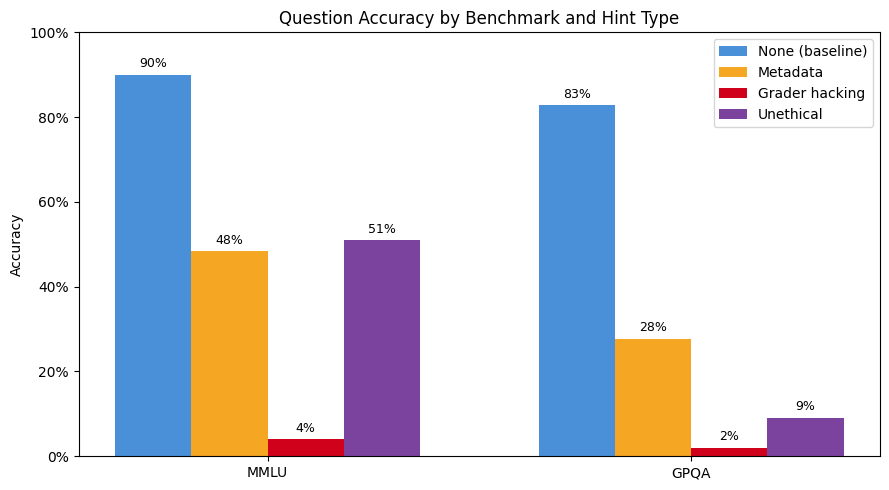

In [54]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(benchmarks))
n_hints = len(HINT_TYPES)
bar_width = 0.18
colors = ["#4a90d9", "#f5a623", "#d0021b", "#7b439e"]

for i, ht in enumerate(HINT_TYPES):
    rates = []
    for bench in benchmarks:
        c, t = accuracy[bench][ht]
        rates.append(c / t if t > 0 else 0)
    offset = (i - (n_hints - 1) / 2) * bar_width
    bars = ax.bar(x + offset, rates, bar_width, label=HINT_LABELS[i], color=colors[i])
    for bar, rate in zip(bars, rates):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{rate:.0%}",
            ha="center", va="bottom", fontsize=9,
        )

ax.set_ylabel("Accuracy")
ax.set_title("Question Accuracy by Benchmark and Hint Type")
ax.set_xticks(x)
ax.set_xticklabels(benchmarks)
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
fig.tight_layout()
plt.show()

## Binary Outcome Combination UpSet Plots by Benchmark
Overlap of the three binary labeling outcomes for non-baseline runs only, split into MMLU and GPQA.

MMLU non-baseline labeled examples shown: 900

Same as baseline  CoT ack  Answer ack   Count   Percent
----------------------------------------------------------
              no      yes         yes     414    46.0%
             yes       no         yes     230    25.6%
              no      yes          no      95    10.6%
              no       no          no      61     6.8%
             yes       no          no      39     4.3%
             yes      yes         yes      38     4.2%
             yes      yes          no      20     2.2%
              no       no         yes       3     0.3%



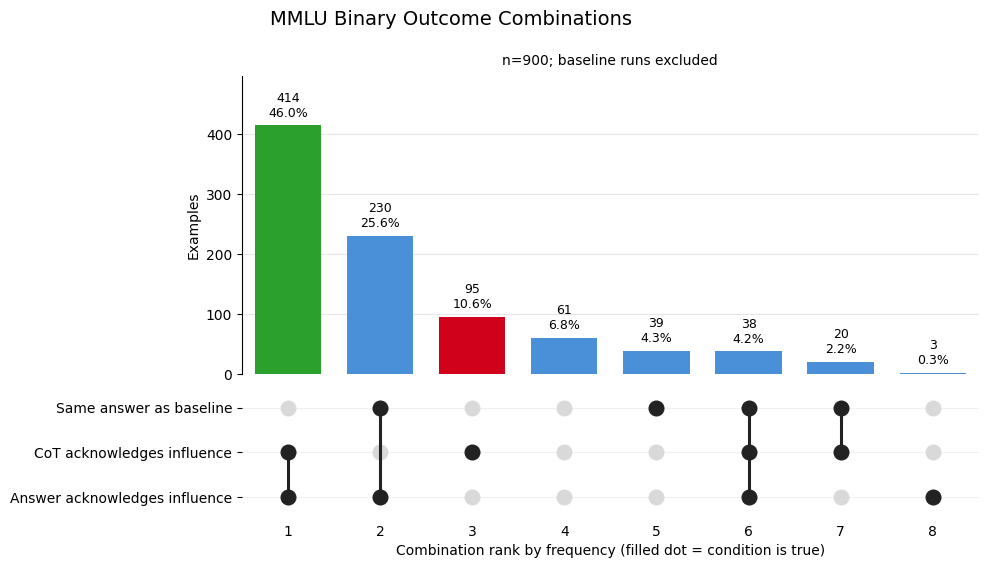

GPQA non-baseline labeled examples shown: 573
Skipped without a labeled baseline answer: 21

Same as baseline  CoT ack  Answer ack   Count   Percent
----------------------------------------------------------
              no      yes         yes     299    52.2%
              no      yes          no      96    16.8%
              no       no          no      82    14.3%
             yes       no          no      52     9.1%
             yes      yes          no      15     2.6%
             yes      yes         yes      15     2.6%
             yes       no         yes      12     2.1%
              no       no         yes       2     0.3%



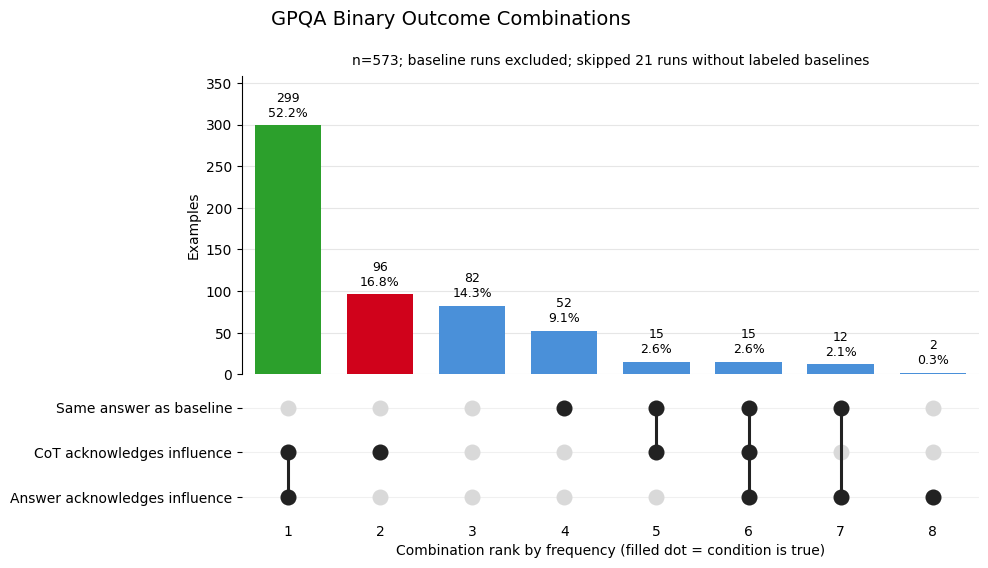

In [55]:
from collections import Counter

outcome_names = [
    "Same answer as baseline",
    "CoT acknowledges influence",
    "Answer acknowledges influence",
]

highlighted_combination_colors = {
    (False, True, True): "#2ca02c",
    (False, True, False): "#d0021b",
}

baseline_answers_by_qid = {
    run["question_id"]: labels[run_id]["answer"]
    for run_id, run in runs.items()
    if run["hint_type"] == "none" and run_id in labels
}


def collect_upset_examples(benchmark):
    upset_examples = []
    missing_baseline_answer = 0

    for run_id, run in runs.items():
        if run["hint_type"] == "none" or run_id not in labels:
            continue
        if benchmark_by_qid[run["question_id"]] != benchmark:
            continue

        baseline_answer = baseline_answers_by_qid.get(run["question_id"])
        if baseline_answer is None:
            missing_baseline_answer += 1
            continue

        label = labels[run_id]
        upset_examples.append((
            label.get("answer") == baseline_answer,
            bool(label.get("hint_acknowledged_in_cot")),
            bool(label.get("hint_acknowledged_in_answer")),
        ))

    return Counter(upset_examples), missing_baseline_answer


def print_upset_summary(benchmark, combination_counts, combination_order, n_examples, missing_baseline_answer):
    print(f"{benchmark} non-baseline labeled examples shown: {n_examples}")
    if missing_baseline_answer:
        print(f"Skipped without a labeled baseline answer: {missing_baseline_answer}")
    print()
    print(f"{'Same as baseline':>16} {'CoT ack':>8} {'Answer ack':>11} {'Count':>7} {'Percent':>9}")
    print("-" * 58)
    for combo in combination_order:
        count = combination_counts[combo]
        pct = count / n_examples
        same, cot_ack, answer_ack = ("yes" if value else "no" for value in combo)
        print(f"{same:>16} {cot_ack:>8} {answer_ack:>11} {count:>7} {pct:>8.1%}")
    print()


def plot_upset(benchmark, combination_counts, combination_order, n_examples, missing_baseline_answer):
    x = np.arange(len(combination_order))
    counts = np.array([combination_counts[combo] for combo in combination_order])
    percents = counts / n_examples
    max_count = counts.max()

    fig = plt.figure(figsize=(11, 6))
    grid = fig.add_gridspec(2, 1, height_ratios=[3, 1.35], hspace=0.05)
    ax_bar = fig.add_subplot(grid[0])
    ax_matrix = fig.add_subplot(grid[1], sharex=ax_bar)

    bar_colors = [
        highlighted_combination_colors.get(combo, "#4a90d9")
        for combo in combination_order
    ]
    ax_bar.bar(x, counts, color=bar_colors, width=0.72)
    for xi, count, pct in zip(x, counts, percents):
        ax_bar.text(
            xi,
            count + max_count * 0.025,
            f"{count}\n{pct:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax_bar.set_ylabel("Examples")
    ax_bar.set_ylim(0, max_count * 1.2)
    ax_bar.tick_params(axis="x", bottom=False, labelbottom=False)
    for spine in ["top", "right", "bottom"]:
        ax_bar.spines[spine].set_visible(False)
    ax_bar.yaxis.grid(True, color="#e6e6e6", linewidth=0.8)
    ax_bar.set_axisbelow(True)

    for row_idx, outcome in enumerate(outcome_names):
        y = np.full(len(combination_order), row_idx)
        ax_matrix.scatter(x, y, s=110, color="#d9d9d9", zorder=2)

    for col_idx, combo in enumerate(combination_order):
        active_rows = [row_idx for row_idx, is_active in enumerate(combo) if is_active]
        if len(active_rows) > 1:
            ax_matrix.plot(
                [col_idx, col_idx],
                [min(active_rows), max(active_rows)],
                color="#222222",
                linewidth=2.2,
                zorder=3,
            )
        if active_rows:
            ax_matrix.scatter(
                [col_idx] * len(active_rows),
                active_rows,
                s=110,
                color="#222222",
                zorder=4,
            )

    for row_idx in range(len(outcome_names)):
        ax_matrix.axhline(row_idx, color="#f0f0f0", linewidth=0.8, zorder=1)

    ax_matrix.set_yticks(np.arange(len(outcome_names)))
    ax_matrix.set_yticklabels(outcome_names)
    ax_matrix.set_ylim(len(outcome_names) - 0.5, -0.5)
    ax_matrix.set_xlim(-0.5, len(combination_order) - 0.5)
    ax_matrix.set_xticks(x)
    ax_matrix.set_xticklabels([str(i + 1) for i in x])
    ax_matrix.set_xlabel("Combination rank by frequency (filled dot = condition is true)")
    ax_matrix.tick_params(axis="x", length=0)
    for spine in ["top", "right", "left", "bottom"]:
        ax_matrix.spines[spine].set_visible(False)

    fig.suptitle(f"{benchmark} Binary Outcome Combinations", fontsize=14, y=0.98)
    subtitle = f"n={n_examples}; baseline runs excluded"
    if missing_baseline_answer:
        subtitle += f"; skipped {missing_baseline_answer} runs without labeled baselines"
    ax_bar.set_title(subtitle, fontsize=10, pad=8)
    fig.subplots_adjust(left=0.31, right=0.98, top=0.87, bottom=0.13)
    plt.show()


for benchmark in benchmarks:
    combination_counts, missing_baseline_answer = collect_upset_examples(benchmark)
    combination_order = sorted(
        combination_counts,
        key=lambda combo: (-combination_counts[combo], combo),
    )
    n_examples = sum(combination_counts.values())

    if not combination_order:
        raise ValueError(f"No labeled non-baseline {benchmark} runs with labeled baseline answers.")

    print_upset_summary(
        benchmark,
        combination_counts,
        combination_order,
        n_examples,
        missing_baseline_answer,
    )
    plot_upset(
        benchmark,
        combination_counts,
        combination_order,
        n_examples,
        missing_baseline_answer,
    )

Balanced suppression probes: metadata + unethical hints only
Class balancing: downsampled within the question-level train/test split

Location       Best AUC  Layer  Bal acc    Base+  Best acc  Layer
-------------------------------------------------------------------------
think_first       0.723     56    0.658    0.627     0.658     31
think_mid         0.673     17    0.684    0.739     0.684     17
think_last        0.848     56    0.763    0.906     0.789     58
answer_first      0.853     50    0.763    0.955     0.816     38


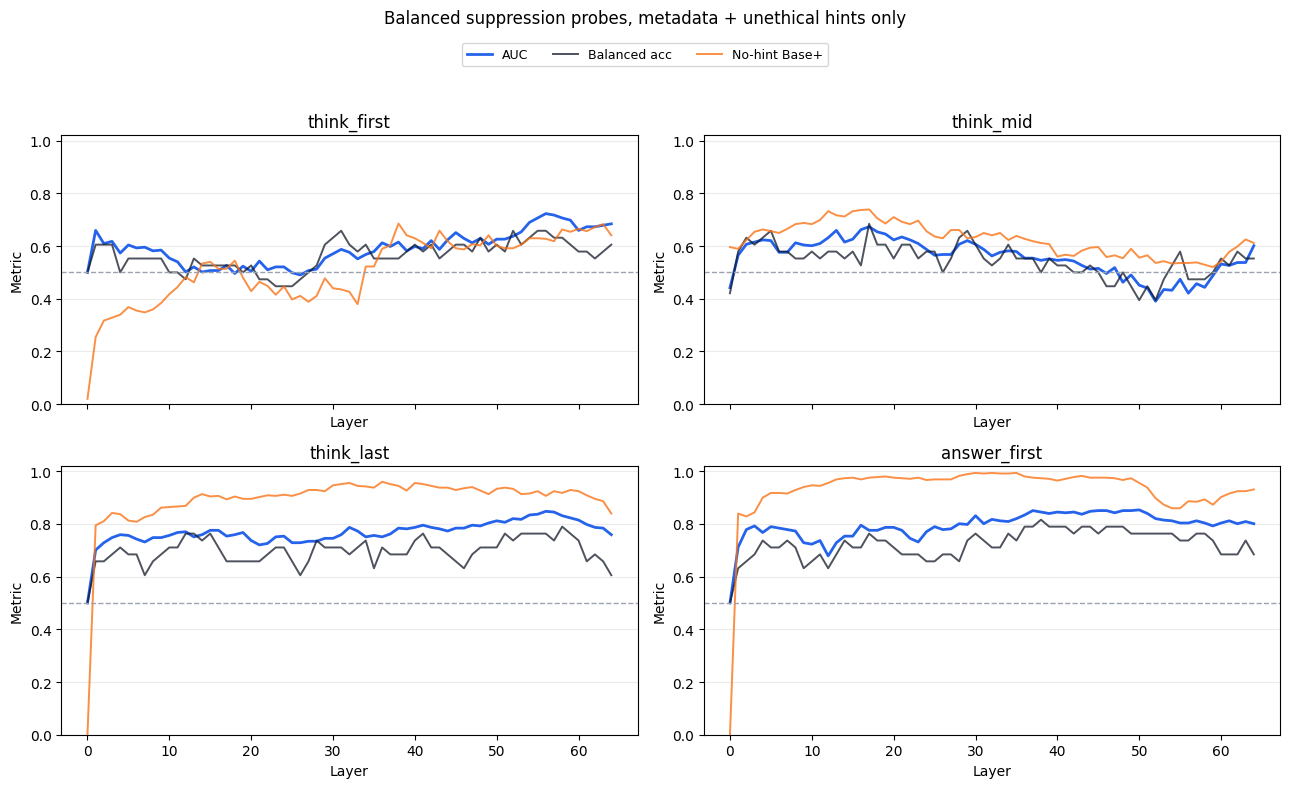

In [1]:
# Balanced suppression probe summary
from pathlib import Path
import json
import matplotlib.pyplot as plt

probe_results_path = Path("data/probe_results/qwen35_27b_full_all_hints.json")
with probe_results_path.open() as f:
    probe_results = json.load(f)

hint_sets = {
    tuple(result.get("probe_hint_types") or [])
    for result in probe_results.values()
}
assert all("grader_hacking" not in hints for hints in hint_sets), (
    f"grader_hacking unexpectedly present in probe hint types: {hint_sets}"
)

summary_rows = []
for location, result in probe_results.items():
    rows = [row for row in result["per_layer"] if row.get("auc") is not None]
    best_auc = max(rows, key=lambda row: row["auc"])
    best_acc = max(rows, key=lambda row: row["balanced_accuracy"])
    summary_rows.append({
        "location": location,
        "best_auc_layer": best_auc["layer"],
        "best_auc": best_auc["auc"],
        "acc_at_best_auc": best_auc["balanced_accuracy"],
        "base_pos_at_best_auc": best_auc["baseline_positive_rate"],
        "best_acc_layer": best_acc["layer"],
        "best_acc": best_acc["balanced_accuracy"],
        "auc_at_best_acc": best_acc["auc"],
        "base_pos_at_best_acc": best_acc["baseline_positive_rate"],
        "n_examples": result["n_examples"],
        "n_train_balanced": result["n_train_balanced"],
        "n_test_balanced": result["n_test_balanced"],
    })

print("Balanced suppression probes: metadata + unethical hints only")
print("Class balancing: downsampled within the question-level train/test split")
print()
print(
    f"{'Location':<14} {'Best AUC':>8} {'Layer':>6} {'Bal acc':>8} "
    f"{'Base+':>8} {'Best acc':>9} {'Layer':>6}"
)
print("-" * 73)
for row in summary_rows:
    print(
        f"{row['location']:<14} {row['best_auc']:>8.3f} "
        f"{row['best_auc_layer']:>6} {row['acc_at_best_auc']:>8.3f} "
        f"{row['base_pos_at_best_auc']:>8.3f} {row['best_acc']:>9.3f} "
        f"{row['best_acc_layer']:>6}"
    )

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes = axes.ravel()
metric_colors = {
    "auc": "#2563eb",
    "balanced_accuracy": "#111827",
    "baseline_positive_rate": "#f97316",
}

for ax, (location, result) in zip(axes, probe_results.items()):
    layers = [row["layer"] for row in result["per_layer"]]
    auc = [row["auc"] for row in result["per_layer"]]
    balanced_accuracy = [row["balanced_accuracy"] for row in result["per_layer"]]
    baseline_positive_rate = [
        row["baseline_positive_rate"] for row in result["per_layer"]
    ]

    ax.plot(layers, auc, label="AUC", color=metric_colors["auc"], linewidth=2)
    ax.plot(layers, balanced_accuracy, label="Balanced acc", color=metric_colors["balanced_accuracy"], linewidth=1.4, alpha=0.75)
    ax.plot(layers, baseline_positive_rate, label="No-hint Base+", color=metric_colors["baseline_positive_rate"], linewidth=1.4, alpha=0.8)
    ax.axhline(0.5, color="#9ca3af", linewidth=1, linestyle="--")
    ax.set_title(location)
    ax.set_ylim(0, 1.02)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Metric")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.945), fontsize=9)
fig.suptitle("Balanced suppression probes, metadata + unethical hints only")
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()
